In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

df=pd.read_csv("loan_approval_data.csv")
df.head(70)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,66.0,11268.0,6212.0,Salaried,59.0,Married,1.0,676.0,0.0,0.16,2837.0,17591.0,14280.0,48.0,Business,NaN,Not Graduate,Male,MNC,Yes
66,67.0,14185.0,7479.0,Salaried,37.0,Married,3.0,778.0,0.0,0.36,16312.0,26718.0,37303.0,NaN,Business,Urban,Not Graduate,Male,MNC,Yes
67,68.0,8331.0,5408.0,Salaried,40.0,Married,2.0,684.0,0.0,0.16,7034.0,49936.0,28453.0,36.0,Personal,NaN,Graduate,Male,Private,Yes
68,69.0,10571.0,9977.0,Salaried,44.0,Single,1.0,575.0,2.0,0.40,NaN,2696.0,3913.0,24.0,Business,Semiurban,Not Graduate,Male,Unemployed,No


# Handling Missing Values


In [27]:
cat_columns=df.select_dtypes(include=["object"]).columns
num_columns=df.select_dtypes(include=["number"]).columns

In [20]:
num_columns

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [22]:
cat_columns.size+num_columns.size

20

In [21]:
cat_columns

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [16]:
df[num_columns].head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0


In [28]:
from sklearn.impute import SimpleImputer

num_imp=SimpleImputer(strategy="mean")
df[num_columns]=num_imp.fit_transform(df[num_columns])
cat_imp=SimpleImputer(strategy="most_frequent")
df[cat_columns]=cat_imp.fit_transform(df[cat_columns])

In [24]:
df[num_columns]

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
0,1.0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0
1,2.0,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0
2,3.0,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0
3,4.0,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0
4,5.0,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0
996,997.0,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0
997,998.0,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0
998,999.0,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0


In [29]:
df[cat_columns]

,Employment_Status,Marital_Status,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,Salaried,Married,Personal,Urban,Not Graduate,Female,Private,No
1,Salaried,Married,Car,Semiurban,Graduate,Male,Private,No
2,Salaried,Single,Business,Urban,Graduate,Female,Government,Yes
3,Salaried,Married,Business,Rural,Graduate,Female,Government,No
4,Self-employed,Single,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...
995,Salaried,Married,Personal,Urban,Not Graduate,Male,Unemployed,No
996,Self-employed,Married,Business,Urban,Graduate,Female,Government,No
997,Contract,Single,Home,Rural,Graduate,Male,MNC,No
998,Unemployed,Single,Personal,Urban,Graduate,Male,Private,Yes


# EDA -Exploratory Data Analysis

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

In [37]:
op_count=df["Loan_Approved"].value_counts()

In [38]:
op_count

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x1933e684ec0>,
 [Text(-0.6521425375337495, 0.8858386482531919, 'No'),
  Text(0.6521428261765839, -0.8858384357581341, 'Yes')],
 [Text(-0.3557141113820451, 0.48318471722901374, '70.2%'),
  Text(0.3557142688235912, -0.4831846013226186, '29.8%')])

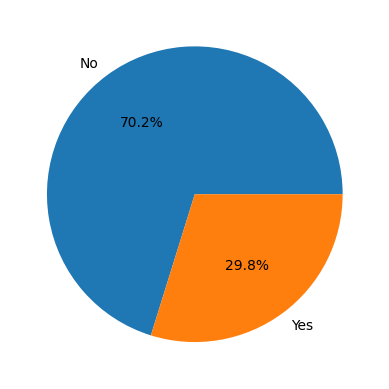

In [39]:
import matplotlib.pyplot as plt
plt.pie(op_count,labels=["No","Yes"],autopct="%1.1f%%")

[Text(0, 0, '621'), Text(0, 0, '379')]

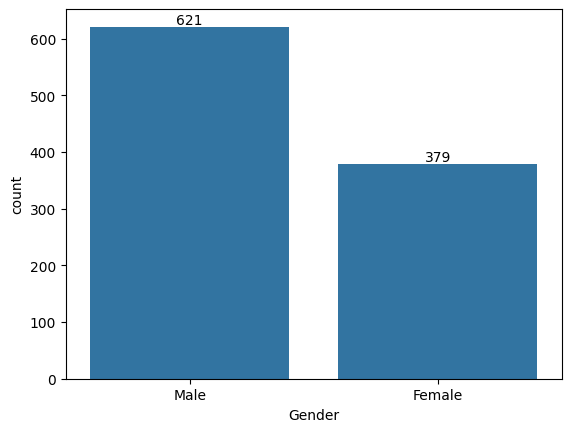

In [46]:
#analysing Categories
gender_count=df["Gender"].value_counts()
plot=sns.barplot(gender_count)
plot.bar_label(plot.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

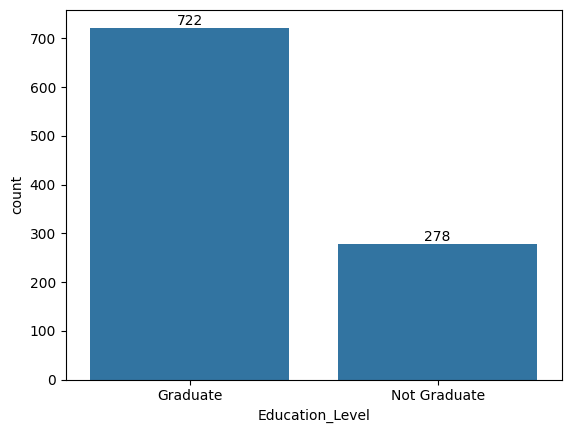

In [48]:
edu_cnt=df["Education_Level"].value_counts()
plot=sns.barplot(edu_cnt)
plot.bar_label(plot.containers[0])

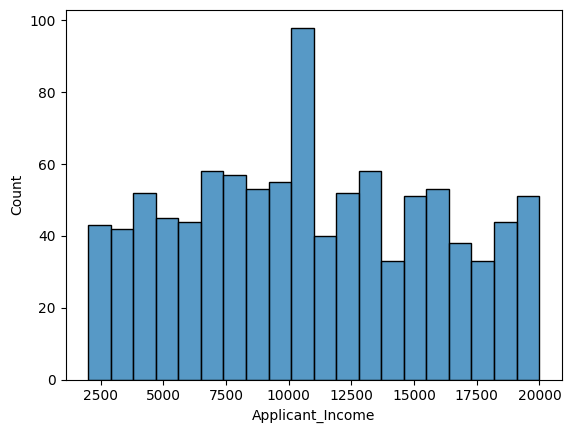

In [49]:
#analysing income
plot=sns.histplot(data=df,
                    x="Applicant_Income",
                  bins=20)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

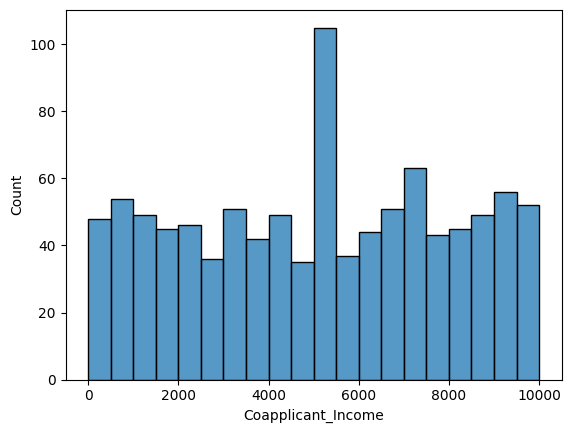

In [50]:
sns.histplot(data=df,
             x="Coapplicant_Income",
             bins=20)

<Axes: xlabel='Loan_Approved', ylabel='Savings'>

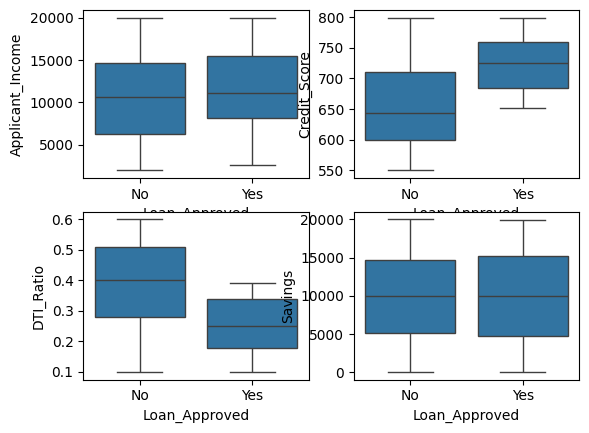

In [55]:
#outlier anaylysis using BOX PLOT
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,
            x="Loan_Approved",
            y="Applicant_Income"
           )
sns.boxplot(ax=axes[0,1],data=df,
            x="Loan_Approved",
            y="Credit_Score"
           )
sns.boxplot(ax=axes[1,0],
            data=df,
            x="Loan_Approved",
            y="DTI_Ratio"
           )
sns.boxplot(ax=axes[1,1],
            data=df,
            x="Loan_Approved",
            y="Savings"
           )

<Axes: xlabel='Credit_Score', ylabel='Count'>

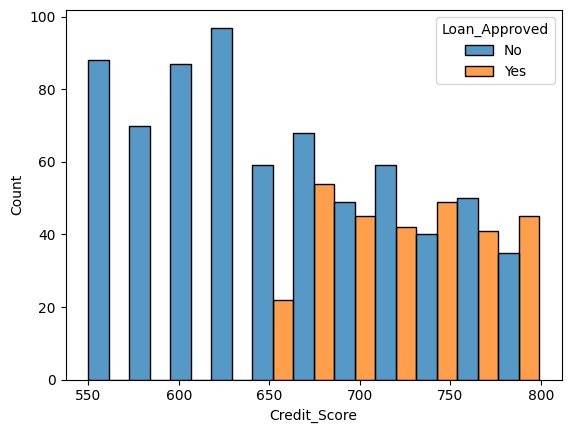

In [57]:
#Anaylysing Credit Score
sns.histplot(data=df,
             x="Credit_Score",
             hue="Loan_Approved",
             multiple="dodge"
            )
             

<Axes: xlabel='Applicant_Income', ylabel='Count'>

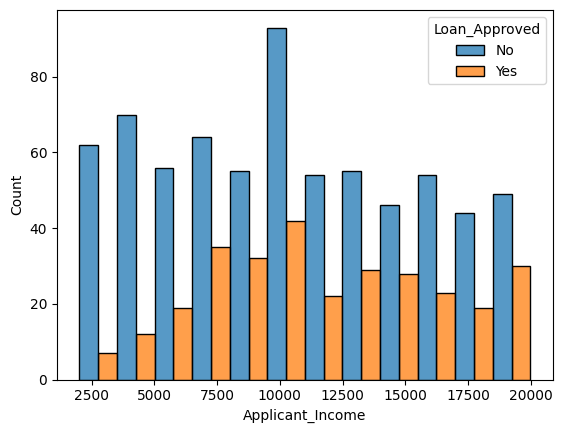

In [58]:
#Anaylysing Applicant Income
sns.histplot(data=df,
             x="Applicant_Income",
             hue="Loan_Approved",
             multiple="dodge"
            )
             

In [ ]:
#CREDIT SCORE IS MORE IMP FEATURE TO DECIDE LOAN APPROVAL
#SUCH DECISIONS ARE MADE WITH EDA using CHARTS like this and observing some pattern


In [61]:
#REMOVE APPLICANT_ID as it doesnt have any work to decide loan_approval
df=df.drop("Applicant_ID",axis=1)

In [62]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes
